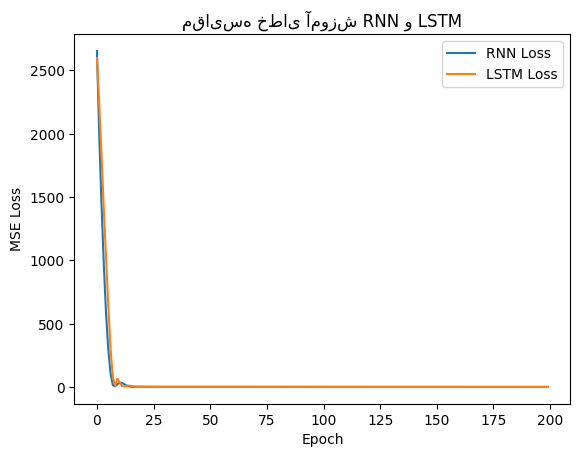

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
import matplotlib.pyplot as plt

# تولید داده toy: دنباله اعداد
def generate_sequence(length):
    X = np.array([i for i in range(length)])
    y = np.array([i + 1 for i in range(length)])
    return X, y

# آماده‌سازی داده برای RNN
def prepare_data(X, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(X[i + time_steps])
    return np.array(Xs), np.array(ys)

# داده
seq_length = 100
X, y = generate_sequence(seq_length)
time_steps = 3
X_train, y_train = prepare_data(X, time_steps)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # [samples, time_steps, features]

# مدل RNN ساده
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(time_steps, 1)))
model_rnn.add(Dense(1))
model_rnn.compile(optimizer='adam', loss='mse')

# مدل LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(time_steps, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# آموزش مدل‌ها
history_rnn = model_rnn.fit(X_train, y_train, epochs=200, verbose=0)
history_lstm = model_lstm.fit(X_train, y_train, epochs=200, verbose=0)

# رسم خطای آموزش
plt.plot(history_rnn.history['loss'], label='RNN Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('مقایسه خطای آموزش RNN و LSTM')
plt.show()


1/1 [==============================] - 0s 102ms/step
RNN Test MSE: 0.0037
LSTM Test MSE: 0.0011


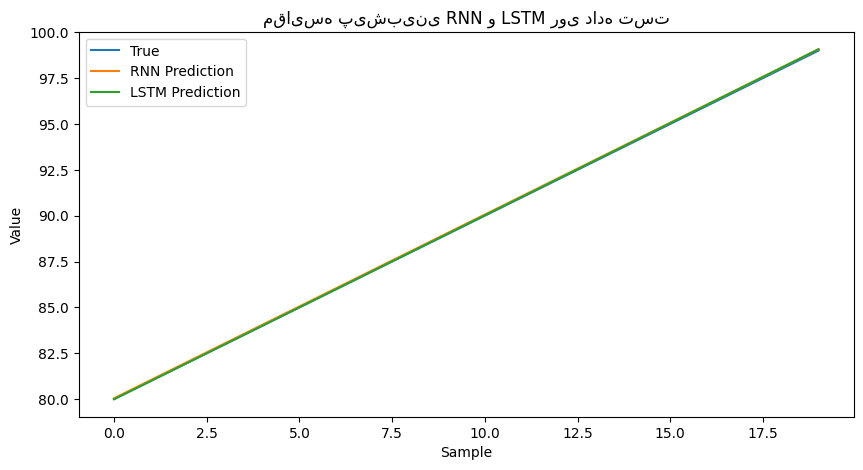

In [2]:
# تقسیم داده به آموزش و تست
split = int(0.8 * len(X_train))
X_train_part, X_test_part = X_train[:split], X_train[split:]
y_train_part, y_test_part = y_train[:split], y_train[split:]

# آموزش دوباره مدل‌ها روی داده آموزش کوچکتر
model_rnn.fit(X_train_part, y_train_part, epochs=200, verbose=0)
model_lstm.fit(X_train_part, y_train_part, epochs=200, verbose=0)

# پیش‌بینی روی داده تست
y_pred_rnn = model_rnn.predict(X_test_part)
y_pred_lstm = model_lstm.predict(X_test_part)

# محاسبه خطا (MSE روی داده تست)
mse_rnn = np.mean((y_pred_rnn.flatten() - y_test_part) ** 2)
mse_lstm = np.mean((y_pred_lstm.flatten() - y_test_part) ** 2)

print(f"RNN Test MSE: {mse_rnn:.4f}")
print(f"LSTM Test MSE: {mse_lstm:.4f}")

# رسم مقایسه پیش‌بینی‌ها
plt.figure(figsize=(10, 5))
plt.plot(y_test_part, label='True')
plt.plot(y_pred_rnn.flatten(), label='RNN Prediction')
plt.plot(y_pred_lstm.flatten(), label='LSTM Prediction')
plt.legend()
plt.title('مقایسه پیش‌بینی RNN و LSTM روی داده تست')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error

# تولید داده سینوسی با نویز
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  # موج 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # موج 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)    # نویز
    return series[..., np.newaxis].astype(np.float32)

# پارامترهای داده
n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_val, y_val = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [2]:
# مدل RNN ساده
model_rnn = Sequential([
    SimpleRNN(20, return_sequences=False, input_shape=[None, 1]),
    Dense(1)
])

# مدل LSTM
model_lstm = Sequential([
    LSTM(20, return_sequences=False, input_shape=[None, 1]),
    Dense(1)
])

# مدل GRU
model_gru = Sequential([
    GRU(20, return_sequences=False, input_shape=[None, 1]),
    Dense(1)
])

models = {
    "RNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru
}

In [3]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.compile(optimizer="adam", loss="mse")
    history = model.fit(X_train, y_train, epochs=20,
                        validation_data=(X_val, y_val))
    
    # ارزیابی روی داده تست
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results[name] = {
        "model": model,
        "history": history.history,
        "mse": mse
    }

Training RNN...
Epoch 1/20
219/219 [==============================] - 5s 17ms/step - loss: 0.0125 - val_loss: 0.0045
Epoch 2/20
219/219 [==============================] - 4s 17ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 3/20
219/219 [==============================] - 3s 16ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 4/20
219/219 [==============================] - 3s 16ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 5/20
219/219 [==============================] - 3s 16ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 6/20
219/219 [==============================] - 4s 16ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 7/20
219/219 [==============================] - 3s 16ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 8/20
219/219 [==============================] - 4s 17ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 9/20
219/219 [==============================] - 4s 17ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 10/20
219/219 [==============================] - 4s 17ms/step - loss:


Mean Squared Error (MSE) on Test Set:
RNN: 0.003111
LSTM: 0.003077
GRU: 0.003315


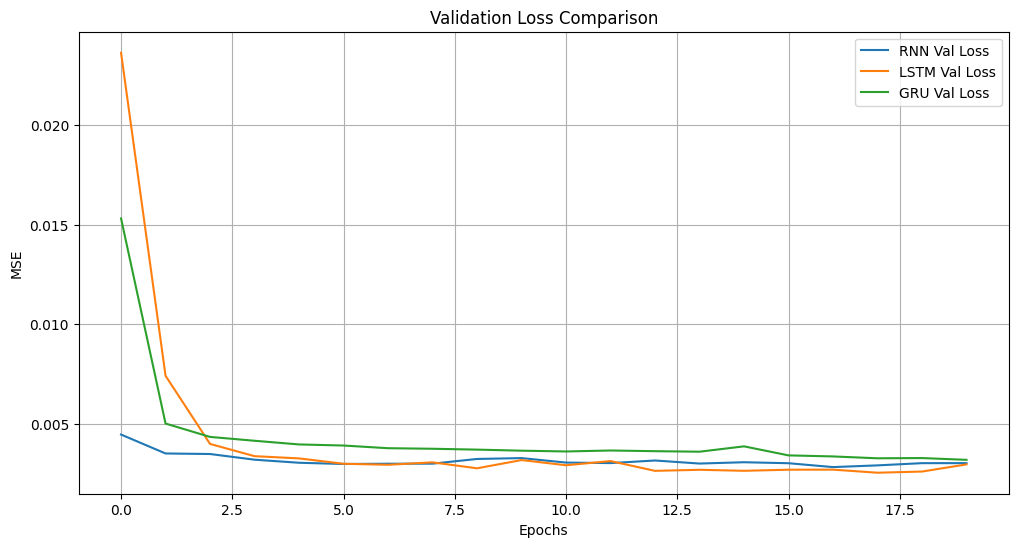

1/1 [==============================] - 0s 17ms/step


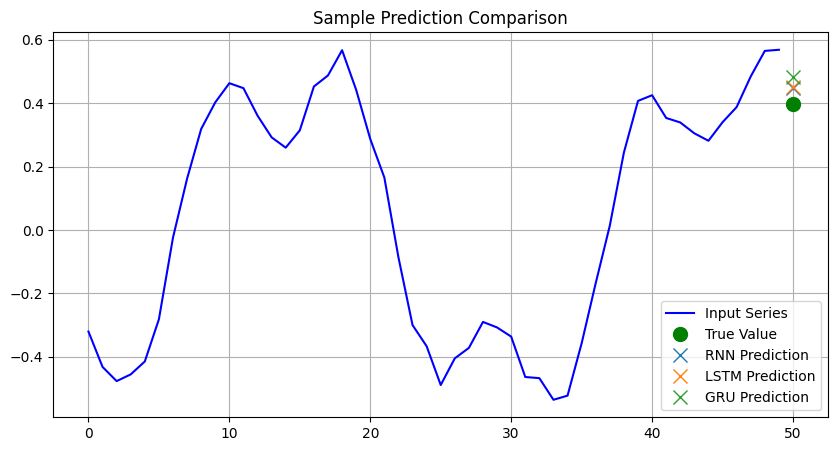

In [4]:
# نمایش MSE
print("\nMean Squared Error (MSE) on Test Set:")
for name, res in results.items():
    print(f"{name}: {res['mse']:.6f}")

# رسم نمودارهای یادگیری
plt.figure(figsize=(12, 6))
for name, res in results.items():
    plt.plot(res['history']['val_loss'], label=f"{name} Val Loss")

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# پیش‌بینی روی نمونه‌ای از داده تست
sample_idx = 0
x_sample, y_true = X_test[sample_idx:sample_idx+1], y_test[sample_idx]

plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_steps), x_sample[0, :, 0], 'b-', label='Input Series')
plt.plot(n_steps, y_true, 'go', markersize=10, label='True Value')

for name, res in results.items():
    y_pred = res['model'].predict(x_sample)[0][0]
    plt.plot(n_steps, y_pred, 'x', markersize=10, label=f'{name} Prediction')

plt.title('Sample Prediction Comparison')
plt.legend()
plt.grid(True)
plt.show()

Physical devices cannot be modified after being initialized
X_train shape: (7000, 50, 1)
y_train shape: (7000, 1)

Training RNN...
Epoch 1/50
28/28 [==============================] - 1s 25ms/step - loss: 0.0135 - mae: 0.0925 - val_loss: 0.0106 - val_mae: 0.0822
Epoch 2/50
28/28 [==============================] - 0s 18ms/step - loss: 0.0103 - mae: 0.0811 - val_loss: 0.0104 - val_mae: 0.0811
Epoch 3/50
28/28 [==============================] - 0s 17ms/step - loss: 0.0101 - mae: 0.0804 - val_loss: 0.0104 - val_mae: 0.0814
Epoch 4/50
28/28 [==============================] - 0s 17ms/step - loss: 0.0100 - mae: 0.0801 - val_loss: 0.0103 - val_mae: 0.0808
Epoch 5/50
28/28 [==============================] - 1s 18ms/step - loss: 0.0100 - mae: 0.0800 - val_loss: 0.0104 - val_mae: 0.0813
Epoch 6/50
28/28 [==============================] - 1s 18ms/step - loss: 0.0101 - mae: 0.0805 - val_loss: 0.0102 - val_mae: 0.0808
Epoch 7/50
28/28 [==============================] - 1s 19ms/step - loss: 0.0100 - m

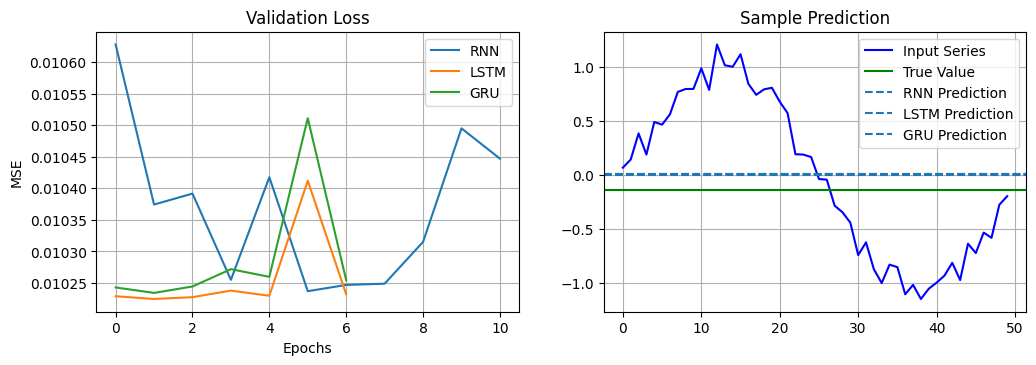

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# تنظیمات GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# تولید داده‌های ساده‌تر برای تست
def generate_time_series(batch_size, n_steps):
    t = np.linspace(0, 10, n_steps + 1)
    series = np.sin(t * 2 * np.pi * 0.1)  # سیگنال سینوسی پایه
    series = np.tile(series, (batch_size, 1)) 
    series += 0.1 * np.random.randn(batch_size, n_steps + 1)
    return series[..., np.newaxis].astype(np.float32)

# پارامترها
n_steps = 50
n_features = 1
batch_size = 256
epochs = 50

# تولید و تقسیم داده‌ها
series = generate_time_series(10000, n_steps)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_val, y_val = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

# بررسی شکل داده‌ها
print(f"X_train shape: {X_train.shape}")  # باید (7000, 50, 1) باشد
print(f"y_train shape: {y_train.shape}")  # باید (7000, 1) باشد

# ساخت مدل‌ها
def build_model(model_type, input_shape):
    model = Sequential()
    model.add(model_type(64, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    return model

models = {
    "RNN": build_model(SimpleRNN, (n_steps, n_features)),
    "LSTM": build_model(LSTM, (n_steps, n_features)),
    "GRU": build_model(GRU, (n_steps, n_features))
}

# آموزش مدل‌ها
optimizer = Adam(learning_rate=0.001)
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # ارزیابی
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results[name] = {
        "model": model,
        "history": history.history,
        "mse": mse,
        "mae": test_mae,
        "params": model.count_params()
    }

# نمایش نتایج
print("\nModel Comparison Summary:")
print("{:<10} {:<15} {:<15} {:<15}".format(
    "Model", "MSE", "MAE", "Params"))
for name, res in results.items():
    print("{:<10} {:<15.6f} {:<15.6f} {:<15}".format(
        name, res['mse'], res['mae'], res['params']))

# رسم نمودارها
plt.figure(figsize=(12, 8))

# نمودار خطا
plt.subplot(2, 2, 1)
for name, res in results.items():
    plt.plot(res['history']['val_loss'], label=f'{name}')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# پیش‌بینی روی نمونه تست
sample_idx = 0
x_sample, y_true = X_test[sample_idx:sample_idx+1], y_test[sample_idx]

plt.subplot(2, 2, 2)
plt.plot(np.arange(n_steps), x_sample[0, :, 0], 'b-', label='Input Series')
plt.axhline(y=y_true[0], color='g', linestyle='-', label='True Value')

for name, res in results.items():
    y_pred = res['model'].predict(x_sample)[0][0]
    plt.axhline(y=y_pred, linestyle='--', label=f'{name} Prediction')

plt.title('Sample Prediction')
plt.legend()
plt.grid(True)
plt.show()